[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pnnl/FragNet/blob/master/fragnet/notebooks/FragNet.ipynb)

# FragNet Interpretability Demo

This notebook demonstrates FragNet's interpretability features, including:
- Atom-level attention weights
- Fragment-level attributions
- Connection weights between fragments
- Support for multiple property predictions (Solubility, Lipophilicity, Energy, Drug Response)

# Install Fragnet

In [1]:
# Uncomment and run if using Google Colab
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric
!pip install -q rdkit
!pip install -q lmdb networkx omegaconf pandas matplotlib scikit-learn scipy tqdm tensorboard pytorch-lightning
# !pip install -q streamlit streamlit-ketcher  # Optional: only needed for Streamlit features

# Clone the FragNet repository (if not already cloned)
!git clone https://github.com/pnnl/FragNet.git
%cd FragNet
!pip install -e .

  Preparing metadata (setup.py) ... done
fatal: destination path 'FragNet' already exists and is not an empty directory.
/content/FragNet
Obtaining file:///content/FragNet
  Preparing metadata (setup.py) ... done
  Attempting uninstall: fragnet
    Found existing installation: fragnet 0.1.0
    Uninstalling fragnet-0.1.0:
      Successfully uninstalled fragnet-0.1.0
  Running setup.py develop for fragnet


Torch Scatter has to be installed seperately. First check the torch version and then run the installation command using the installed torch version.

In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cpu
None


In [3]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.1.0+cpu.html

## 1. Import Required Libraries

In [4]:
# Core imports
import pandas as pd
from pathlib import Path
import base64
from rdkit import Chem
# FragNet imports
from fragnet.vizualize.viz import FragNetVizApp
from fragnet.vizualize.model import FragNetPreTrainViz
from fragnet.vizualize.model_attr import get_attr_image


## 2. Helper Functions

In [15]:
def resolve_prop_model(prop_type):
    """
    Load the appropriate model based on property type.

    Args:
        prop_type: One of 'Solubility', 'Lipophilicity', or 'Energy'

    Returns:
        viz: FragNetVizApp instance
        prop_prediction: Predicted property value
        model_config: Path to model configuration
        chkpt_path: Path to model checkpoint
    """
    if prop_type == 'Solubility':
        model_config = './fragnet/exps/ft/pnnl_full/fragnet_hpdl_exp1s_h4pt4_10/config_exp100.yaml'
        chkpt_path = './fragnet/exps/ft/pnnl_full/fragnet_hpdl_exp1s_h4pt4_10/ft_100.pt'
        viz = FragNetVizApp(model_config, chkpt_path)
        prop_prediction = viz.calc_weights(selected)

    elif prop_type == 'Lipophilicity':
        model_config = './fragnet/exps/ft/lipo/fragnet_hpdl_exp1s_pt4_30/config_exp100.yaml'
        chkpt_path = './fragnet/exps/ft/lipo/fragnet_hpdl_exp1s_pt4_30/ft_100.pt'
        viz = FragNetVizApp(model_config, chkpt_path)
        prop_prediction = viz.calc_weights(selected)

    elif prop_type == 'Energy':
        model_config = './fragnet/fragnet/exps/pt/unimol_exp1s4/config.yaml'
        chkpt_path = './fragnet/fragnet/exps/pt/unimol_exp1s4/pt.pt'
        viz = FragNetVizApp(model_config, chkpt_path, 'energy')
        prop_prediction = viz.calc_weights(selected)

    return viz, prop_prediction, model_config, chkpt_path


def resolve_DRP(smiles, cell_line, cell_line_df):
    """
    Load Drug Response Prediction (DRP) model.

    Args:
        smiles: SMILES string of the molecule
        cell_line: Name of the cell line
        cell_line_df: DataFrame containing gene expression data

    Returns:
        viz: FragNetVizApp instance
        prop_prediction: Predicted drug response
        model_config: Path to model configuration
        chkpt_path: Path to model checkpoint
    """
    model_config = '../exps/ft/gdsc/fragnet_hpdl_exp1s_pt4_30/config_exp100.yaml'
    chkpt_path = '../exps/ft/gdsc/fragnet_hpdl_exp1s_pt4_30/ft_100.pt'
    viz = FragNetVizApp(model_config, chkpt_path, 'cdrp')

    gene_expr = cell_line_df.loc[cell_line, :].values
    viz.calc_weights_cdrp(smiles, gene_expr)
    prop_prediction = -1

    return viz, prop_prediction, model_config, chkpt_path

In [ ]:
# Get bond weights
def get_bond_weights(viz):

  bonds = viz.mol.GetBonds()

  atoms_in_bonds = []
  for i, b in enumerate(bonds):
    atoms_in_bonds.append([b.GetBeginAtomIdx(), b.GetEndAtomIdx(), viz.bond_weights_sc[i]])

  atoms_in_bonds = pd.DataFrame(atoms_in_bonds, columns=['Atom 1', 'Atom 2', 'Bond Weight'])
  atoms_in_bonds.sort_values(by='Bond Weight', ascending=False, inplace=True)

  return atoms_in_bonds

## 4. Load Model and Make Prediction

In [9]:
# Choose property type: 'Solubility', 'Lipophilicity', or 'Energy'
prop_type = "Solubility"

# Example molecule: diphenhydramine hydrochloride
selected = 'CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]'

In [ ]:
if prop_type in ["Solubility", "Lipophilicity", "Energy"]:
    viz, prop_prediction, model_config, chkpt_path = resolve_prop_model(prop_type)

In [11]:
print(f"Predicted {prop_type}: {prop_prediction:.4f}")

Predicted Solubility: -3.9508


-3.9507532119750977

In [27]:
# df_atom_contrib, df_bond_contrib, df_fbond_contrib = viz.get_all_contributions(prop_type)

## 5. Atom-Level Interpretability

### Atom Weights

In [17]:
# Configure visualization settings
hide_bond_weights = True
hide_atom_weights = False

# Generate atom weight visualization
png, atom_weights = viz.vizualize_atom_weights(hide_bond_weights, hide_atom_weights)

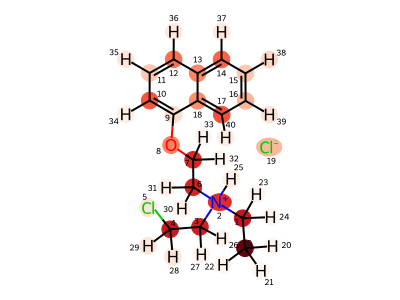

In [18]:
png

### Atom Weight Values

In [19]:
# Create DataFrame for easier viewing
attn_atoms = pd.DataFrame(atom_weights)
attn_atoms.index.rename('Atom Index', inplace=True)
attn_atoms.columns = ['Atom Weights']

In [20]:
attn_atoms

,Atom Weights
Atom Index,
0,8.648284
1,7.188109
2,6.596666
3,6.898057
4,7.058699
5,2.980634
6,6.802772
7,6.697472
8,5.025870


Atom Contribution Values

In [ ]:
df_atom = viz.calc_atom_contributions(viz.data_item, prop_type)

In [30]:
df_atom

,atom_index,atom_type,attr,pred_no_mask,pred_mask
0,0,C,-0.106288,-3.950753,-3.844465
1,1,C,0.185241,-3.950753,-4.135994
2,2,N,-0.070400,-3.950753,-3.880353
3,3,C,0.218759,-3.950753,-4.169512
4,4,C,-0.575412,-3.950753,-3.375342
5,5,Cl,-0.239666,-3.950753,-3.711087
6,6,C,0.312851,-3.950753,-4.263604
7,7,C,0.396805,-3.950753,-4.347558
8,8,O,0.138387,-3.950753,-4.089140
9,9,C,-0.422341,-3.950753,-3.528412


### Bond Weights

In [36]:
# Configure visualization settings
hide_bond_weights = False
hide_atom_weights = True

# Generate atom weight visualization
png_bonds, _ = viz.vizualize_atom_weights(hide_bond_weights, hide_atom_weights)

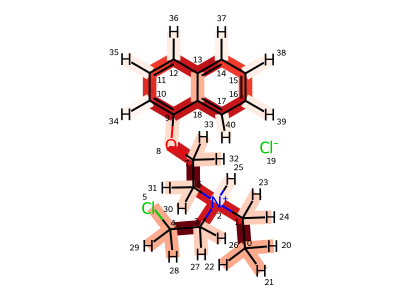

In [37]:
# Bond Weights Visualization
png_bonds

Display bond weight values

In [46]:
df_bond_weights = get_bond_weights(viz)

In [47]:
df_bond_weights

,Atom 1,Atom 2,Bond Weight
6,6,7,1.000000
0,0,1,0.999551
3,3,4,0.996853
13,13,14,0.801531
17,17,18,0.800940
9,9,10,0.779872
18,18,9,0.775775
16,16,17,0.763058
12,12,13,0.758965
1,1,2,0.744555


Display Bond Contribution Values

In [ ]:
df_bond_contributions = viz.calc_bond_contributions(viz.data_item, prop_type)

In [49]:
df_bond_contributions

,bond_index,bond_type,begin_atom,end_atom,attr,pred_no_mask,pred_mask
0,0,SINGLE,6,6,0.463061,-3.950753,-4.413815
1,2,SINGLE,6,7,0.746735,-3.950753,-4.697488
2,4,SINGLE,7,6,0.494349,-3.950753,-4.445102
3,6,SINGLE,6,6,0.158076,-3.950753,-4.108829
4,8,SINGLE,6,17,-0.558858,-3.950753,-3.391895
5,10,SINGLE,7,6,0.378474,-3.950753,-4.329227
6,12,SINGLE,6,6,0.101116,-3.950753,-4.051869
7,14,SINGLE,6,8,0.902423,-3.950753,-4.853176
8,16,SINGLE,8,6,0.323954,-3.950753,-4.274707
9,18,AROMATIC,6,6,-0.027551,-3.950753,-3.923202


# Fragment Level Interpretability

In [58]:
png_frag_attn, png_frag_highlight, frag_w, connection_w, atoms_in_frags = viz.frag_weight_highlight()
png_attr, attr_atom_weights, frag_contributions = get_attr_image(selected, model_config, chkpt_path, prop_type)

100%|██████████| 1/1 [00:00<00:00,  8.38it/s]
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead


0.12484407424926758
0.00508427619934082


[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[14:39:23] DEPRECATIO

using FTHead4
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
using FTHead4
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None


In [71]:
# Atom indices of each fragment.
# In this dictionary, keys are fragment indices, values are atom indices of those fragments.
atoms_in_frags

{0: [0, 1, 20, 21, 22, 23, 24],
 1: [2, 25],
 2: [3, 4, 5, 26, 27, 28, 29],
 3: [6, 7, 30, 31, 32, 33],
 4: [8],
 5: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 34, 35, 36, 37, 38, 39, 40],
 6: [19]}

### Fragment Weights

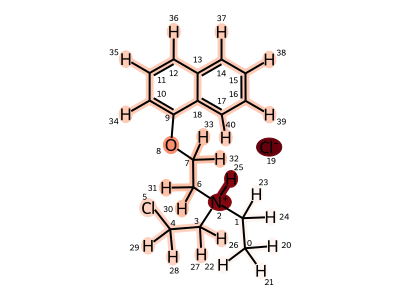

In [59]:
png_frag_attn

In [72]:
# Numerical values of the Fragment Attention Weights
frag_w

,fragment,weight,smiles
0,0.0,1.083533,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
1,1.0,7.635789,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
2,2.0,2.287983,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
3,3.0,2.709953,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
4,4.0,3.762445,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
5,5.0,2.466498,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
6,6.0,8.053800,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]


### Fragment Contributions

In [65]:
# png_attr

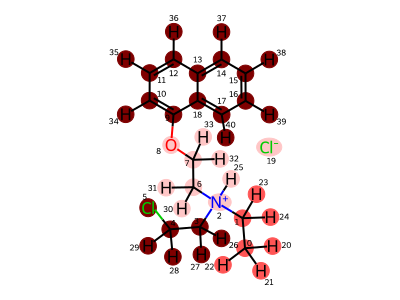

In [67]:
from IPython.display import SVG
SVG(png_attr)

In [74]:
df_frag_contrib = pd.DataFrame(frag_contributions)
df_frag_contrib['atoms'] = df_frag_contrib['atoms'].apply(lambda x: ', '.join(str(a) for a in x))
df_frag_contrib

,fragment_index,atoms,contribution
0,0,"0, 1, 20, 21, 22, 23, 24",-0.288438
1,1,"2, 25",-0.068584
2,2,"3, 4, 5, 26, 27, 28, 29",-0.834798
3,3,"6, 7, 30, 31, 32, 33",-0.125792
4,4,8,-0.028763
5,5,"9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 34, 35,...",-2.841158
6,6,19,-0.003570


# Fragment Connection Level Interpretability

### Fragment Connection Weights

In [75]:
connection_w

,connection,weight,smiles
0,"[0, 1]",7.762414,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
1,"[0, 6]",5.560194,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
2,"[1, 2]",7.762414,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
3,"[1, 3]",11.239227,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
4,"[1, 6]",7.418562,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
5,"[2, 6]",5.560194,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
6,"[3, 4]",9.798031,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
7,"[3, 6]",6.398179,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
8,"[4, 5]",6.064309,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]
9,"[4, 6]",9.497845,CC[NH+](CCCl)CCOc1cccc2ccccc12.[Cl-]


### Fragment Connection Contributions

In [83]:

df_fbond_contrib = viz.calc_fbond_contributions(viz.data_item, prop_type)

bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
bond mask 

In [84]:
df_fbond_contrib

,fragbond_node_index,begin_index,end_index,attr,pred_no_mask,pred_mask
0,0,4,3,-0.006228,-3.950753,-3.944525
1,2,4,5,0.059390,-3.950753,-4.010143
2,4,0,1,0.060201,-3.950753,-4.010954
3,6,2,1,-0.116358,-3.950753,-3.834395
4,8,3,1,-0.076446,-3.950753,-3.874307
5,10,0,6,-0.110788,-3.950753,-3.839965
6,12,1,6,0.026160,-3.950753,-3.976913
7,14,2,6,-0.192842,-3.950753,-3.757911
8,16,3,6,-0.086311,-3.950753,-3.864443
9,18,4,6,0.077120,-3.950753,-4.027873
